# TFM - Modelización predictiva de la demanda para la mejora del dimensionamiento de stock en entornos empresariales

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

---
## 2. Parámetros y configuración

In [2]:
FACTOR_SERVICIO = 1.64
COSTE_UNITARIO = 0.20/365
DATA_RAW = Path('data/raw')
DATA_DIR = Path('data/processed')
OUTPUT_DIR = Path('data/results')
COLORS = {'rojo': '#E63946',
    'verde': '#A8D5BA',
    'azul': '#457B9D',
    'naranja': '#F4A261'}

---
## 3. Carga del conjunto de datos preparado

In [3]:
df_ciclo = pd.read_excel(DATA_RAW / 'DatosCicloAprovisionamiento.xlsx')
df_precio = pd.read_excel(DATA_RAW / 'DatosPrecioMedio.xlsx')
df_cluster = pd.read_parquet(DATA_DIR / 'df_final.parquet')[['producto', 'cluster']].drop_duplicates()

df_rmse = pd.read_csv(OUTPUT_DIR / 'rmse_escenarios.csv')
rmse_model = df_rmse[df_rmse['modelo'] == 'ganador'].set_index('cluster')['RMSE'].to_dict()
rmse_naive = df_rmse[df_rmse['modelo'] == 'naive'].set_index('cluster')['RMSE'].to_dict()

df_prod = (df_cluster
           .merge(df_ciclo, on='producto')
           .merge(df_precio, on='producto'))
df_prod['ciclo_total'] = df_prod['diasEntrePedidos'] + df_prod['diasLeadtime']

In [4]:
display(df_prod.head())

,producto,cluster,diasEntrePedidos,diasLeadtime,eurPrecioMedio,ciclo_total
0,1,0,14,15,68.730000,29
1,2,0,14,15,148.330000,29
2,3,0,14,15,169.000000,29
3,4,0,14,15,0.604383,29
4,5,0,14,15,4.553314,29


---
## 4. Cálculo stock seguridad y coste por producto

In [5]:
def calcular_ss_coste(df_prod, rmse_dict, factor, COSTE_UNITARIO):
    resultados = []
    for _, row in df_prod.iterrows():
        cid = row['cluster']
        rmse = rmse_dict[cid]
        ciclo = row['ciclo_total']
        precio = row['eurPrecioMedio']
        ss = np.ceil(factor * rmse * np.sqrt(ciclo))
        coste_diario = (COSTE_UNITARIO) * precio * ss
        resultados.append({'producto': row['producto'],
            'cluster': cid,
            'ciclo_total': ciclo,
            'precio': round(precio, 4),
            'ss': round(ss, 4),
            'coste_diario': round(coste_diario, 4)})
    return pd.DataFrame(resultados)

df_naive_coste = calcular_ss_coste(df_prod, rmse_naive, FACTOR_SERVICIO, COSTE_UNITARIO)
df_model_coste = calcular_ss_coste(df_prod, rmse_model, FACTOR_SERVICIO, COSTE_UNITARIO)

---
## 5. Resumen por clúster

In [6]:
resumen = pd.DataFrame({
    'cluster': sorted(df_prod['cluster'].unique()),
    'ss_naive': df_naive_coste.groupby('cluster')['ss'].sum().values,
    'ss_model': df_model_coste.groupby('cluster')['ss'].sum().values,
    'coste_diario_naive': df_naive_coste.groupby('cluster')['coste_diario'].sum().values,
    'coste_diario_model': df_model_coste.groupby('cluster')['coste_diario'].sum().values,
}).assign(
    ahorro_diario=lambda x: x['coste_diario_naive'] - x['coste_diario_model'],
    ahorro_anual= lambda x: (x['coste_diario_naive'] - x['coste_diario_model']) * 365
).round(2)

display(resumen)

print(f"Ahorro diario total: {resumen['ahorro_diario'].sum():.2f} €")
print(f"Ahorro anual total: {resumen['ahorro_anual'].sum():.2f} €")

,cluster,ss_naive,ss_model,coste_diario_naive,coste_diario_model,ahorro_diario,ahorro_anual
0,0,5763.0,4098.0,168.68,120.49,48.18,17586.79
1,1,8265.0,5875.0,222.72,158.73,63.99,23357.99
2,2,494.0,218.0,13.81,6.07,7.74,2825.43


Ahorro diario total: 119.91 €
Ahorro anual total: 43770.21 €


---
## 6. Visualización

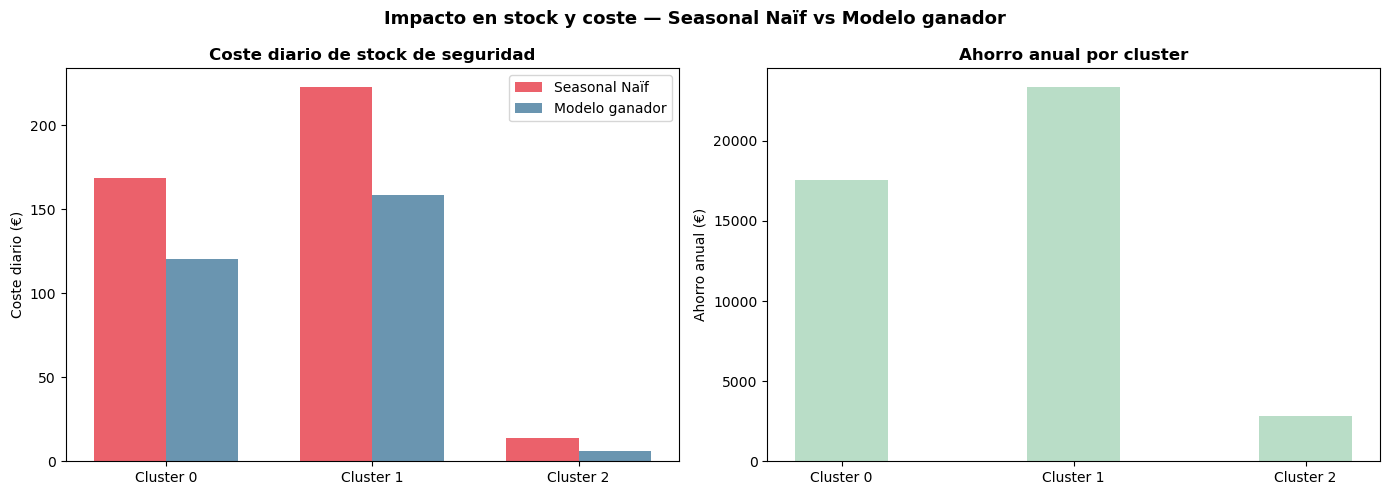

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clusters = resumen['cluster'].tolist()
x = np.arange(len(clusters))
w = 0.35

axes[0].bar(x - w/2, resumen['coste_diario_naive'], width=w,
            label='Seasonal Naïf', color='#E63946', alpha=0.8)
axes[0].bar(x + w/2, resumen['coste_diario_model'], width=w,
            label='Modelo ganador', color='#457B9D', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Cluster {c}' for c in clusters])
axes[0].set_ylabel('Coste diario (€)')
axes[0].set_title('Coste diario de stock de seguridad', fontweight='bold')
axes[0].legend()

axes[1].bar(clusters, resumen['ahorro_anual'], color='#A8D5BA', alpha=0.8, width=0.4)
axes[1].set_xticks(clusters)
axes[1].set_xticklabels([f'Cluster {c}' for c in clusters])
axes[1].set_ylabel('Ahorro anual (€)')
axes[1].set_title('Ahorro anual por cluster', fontweight='bold')

plt.suptitle('Impacto en stock y coste — Seasonal Naïf vs Modelo ganador',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
resumen['reduccion_ss'] = resumen['ss_naive'] - resumen['ss_model']
resumen['pct_reduccion_ss'] = (resumen['reduccion_ss'] / resumen['ss_naive'] * 100).round(2)
resumen['pct_reduccion_coste'] = ((resumen['coste_diario_naive'] - resumen['coste_diario_model']) / resumen['coste_diario_naive'] * 100).round(2)
display(resumen[['cluster', 'ss_naive', 'ss_model', 'reduccion_ss',
                 'pct_reduccion_ss', 'pct_reduccion_coste', 'ahorro_anual']])

,cluster,ss_naive,ss_model,reduccion_ss,pct_reduccion_ss,pct_reduccion_coste,ahorro_anual
0,0,5763.0,4098.0,1665.0,28.89,28.57,17586.79
1,1,8265.0,5875.0,2390.0,28.92,28.73,23357.99
2,2,494.0,218.0,276.0,55.87,56.05,2825.43


In [9]:
# Ahorro por producto 
df_detalle = df_naive_coste.copy()
df_detalle['ahorro_diario'] = df_naive_coste['coste_diario'] - df_model_coste['coste_diario']
df_detalle['ahorro_anual'] = df_detalle['ahorro_diario'] * 365
df_detalle['reduccion_ss'] = df_naive_coste['ss'] - df_model_coste['ss']
df_detalle['precio'] = df_prod['eurPrecioMedio'].values

print('Estadísticas del ahorro anual por producto:')
display(df_detalle['ahorro_anual'].describe().round(2))

Estadísticas del ahorro anual por producto:


count    861.00
mean      50.84
std       76.01
min        0.00
25%        7.74
50%       24.75
75%       62.09
max      800.19
Name: ahorro_anual, dtype: float64

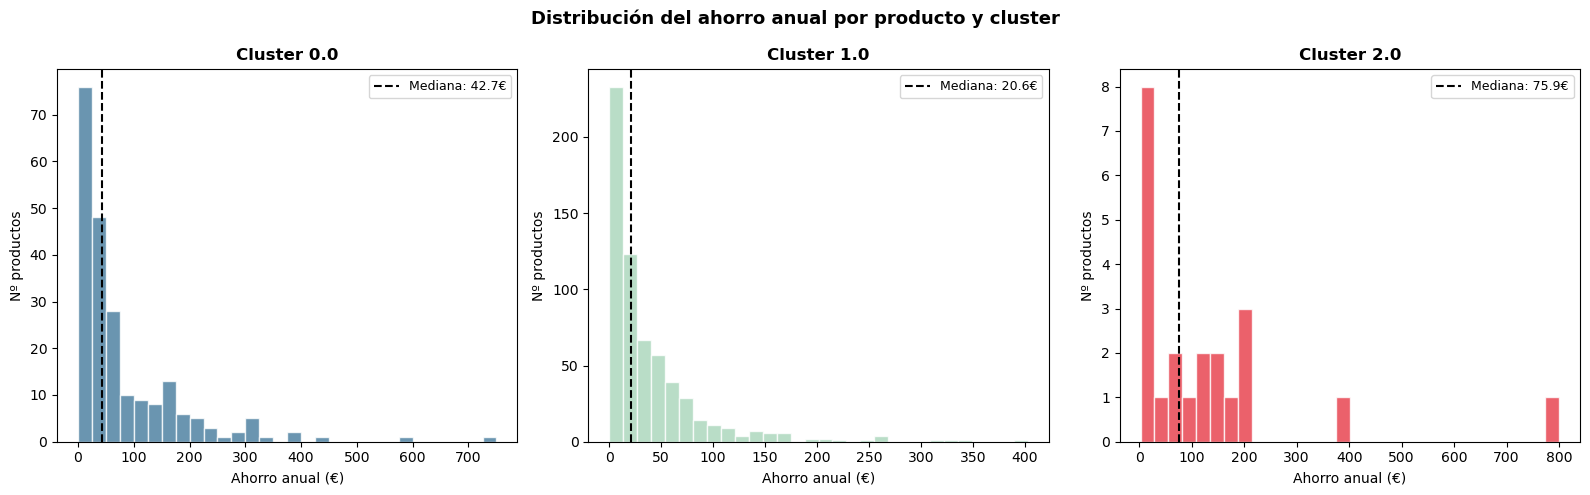

In [10]:
# Histograma ahorro anual por producto
colores = {0: COLORS['azul'], 1: COLORS['verde'], 2: COLORS['rojo']}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for idx, cid in enumerate(sorted(df_detalle['cluster'].unique())):
    datos = df_detalle[df_detalle['cluster'] == cid]['ahorro_anual']
    axes[idx].hist(datos, bins=30, color=colores[cid], alpha=0.8, edgecolor='white')
    axes[idx].axvline(datos.median(), color='black', linewidth=1.5,
                      linestyle='--', label=f'Mediana: {datos.median():.1f}€')
    axes[idx].set_title(f'Cluster {cid}', fontweight='bold')
    axes[idx].set_xlabel('Ahorro anual (€)')
    axes[idx].set_ylabel('Nº productos')
    axes[idx].legend(fontsize=9)

plt.suptitle('Distribución del ahorro anual por producto y cluster',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()